In [53]:
import pandas as pd
import numpy as np

DATA_PATH = r'/home/rlfowler/Documents/research/TFO-Simulator/data/randall_data_EPR.parquet'
# DATA_PATH = r'/home/rlfowler/Documents/research/TFO-Simulator/data/randall_short_EPR.parquet'
# DATA_PATH = r'/home/rlfowler/Documents/research/TFO-Simulator/data/weitai_epr.parquet'

data:pd.DataFrame = pd.read_parquet(DATA_PATH)

if DATA_PATH == r'/home/rlfowler/Documents/research/TFO-Simulator/data/randall_data_EPR.parquet':
    from mtools import data_filter_remove_fr, data_filter_remove_fd

    data = data_filter_remove_fr(data)
    data = data_filter_remove_fd(data)
    
print(data.shape)
data.head()

(204974, 48)


,Maternal Wall Thickness,Fetal Radius,Fetal Displacement,Maternal Hb Concentration,Maternal Saturation,Fetal Hb Concentration 1,Fetal Hb Concentration 2,Fetal Saturation,10.0_1.0,15.0_1.0,...,55.0_2.0,59.0_2.0,64.0_2.0,68.0_2.0,72.0_2.0,77.0_2.0,81.0_2.0,86.0_2.0,90.0_2.0,94.0_2.0
21296,3.0,390.0,0.0,11.0,0.9,10.725,11.0,0.10,1.000955,1.003458,...,1.065443,1.074594,1.057996,1.044402,1.219761,1.082500,1.168695,1.110314,1.328575,1.180589
21297,3.0,390.0,0.0,11.0,0.9,10.725,11.0,0.15,1.000965,1.003458,...,1.065700,1.074654,1.057748,1.044021,1.222227,1.081385,1.169355,1.106645,1.328835,1.181483
21298,3.0,390.0,0.0,11.0,0.9,10.725,11.0,0.20,1.000948,1.003462,...,1.065956,1.074723,1.057521,1.043658,1.224656,1.080346,1.170050,1.103309,1.328634,1.182275
21299,3.0,390.0,0.0,11.0,0.9,10.725,11.0,0.25,1.000935,1.003467,...,1.066212,1.074804,1.057315,1.043312,1.227045,1.079382,1.170768,1.100278,1.327943,1.182959
21300,3.0,390.0,0.0,11.0,0.9,10.725,11.0,0.30,1.000954,1.003466,...,1.066466,1.074894,1.057128,1.042983,1.229387,1.078492,1.171504,1.097522,1.326736,1.183534


In [54]:
from sklearn import preprocessing


if DATA_PATH != r'/home/rlfowler/Documents/research/TFO-Simulator/data/weitai_epr.parquet':
    LABEL_START_INDEX = 8
    output_labels = [7] # Just fetal saturation
    input_labels = [1, 5, 8, 13, 19, 21, 25, 28, 33, 39]
else:
    LABEL_START_INDEX = 6
    output_labels = [3] # Just fetal saturation


input_labels = [1, 5, 8, 13, 19, 21, 25, 28, 33, 39]

x_columns = data.columns[LABEL_START_INDEX:][input_labels]    # Input columns
y_columns = data.columns[:LABEL_START_INDEX][output_labels]    # Output columns

# Normalize the data
x_scalar = preprocessing.StandardScaler()
data[x_columns] = x_scalar.fit_transform(data[x_columns])
y_scalar = preprocessing.StandardScaler().fit(data[y_columns])
# y_scalar = y_scalar.fit(data[y_columns])

In [55]:
print(data.shape)

(204974, 48)


In [56]:
y_scalar.feature_names_in_

array(['Fetal Saturation'], dtype=object)

In [4]:
# import torch
# from torch.utils.data import DataLoader, TensorDataset

# BATH_SIZE = 4096

# dataset = TensorDataset(torch.tensor(data[x_columns].values, dtype=torch.float32).cuda())
# data_loader = DataLoader(dataset, batch_size=BATH_SIZE, shuffle=False)

In [57]:
import os
import sys
os.environ["CUDA_VISIBLE_DEVICES"] = "2"    # GPU 2 - Randall
sys.path.append(r'/home/rlfowler/Documents/research/TFO-Inverse-Modeling')
import torch
from mtools import MLP
from torch import nn
import torch

if DATA_PATH == r'/home/rlfowler/Documents/research/TFO-Simulator/data/weitai_epr.parquet':
    MODEL_FILE = r'/home/rlfowler/Documents/research/TFO-Inverse-Modeling/reports/saved_models/wr_paper_weitai_epr1.pth'

elif DATA_PATH == r'/home/rlfowler/Documents/research/TFO-Simulator/data/randall_short_EPR.parquet':    
    MODEL_FILE = r'/home/rlfowler/Documents/research/TFO-Inverse-Modeling/reports/saved_models/wr_paper_short_epr1.pth'

elif DATA_PATH == r'/home/rlfowler/Documents/research/TFO-Simulator/data/randall_data_EPR.parquet':
    MODEL_FILE = r'/home/rlfowler/Documents/research/TFO-Inverse-Modeling/reports/saved_models/wr_paper_large_epr1.pth'

else:
    raise ValueError("Unknown data path")

hidden_layers = [64, 32, 16, 8]
# hidden_layers = [20, 60, 20, 10]

model = MLP(node_counts=[len(x_columns)] + hidden_layers + [len(y_columns)],
                                    dropout_rates=[0], # Make False if size mismatch
                                    batch_norm=True,
                                    act_funcs=[nn.ReLU()])   # Save entire model to avoid having to re-define the model architecture
# model.eval()

model.load(MODEL_FILE)
# states = torch.load(MODEL_FILE)
# print(states.keys())
# print(states['0.weight'].shape)

# try:
#     model.load_state_dict(states)
    
# except:
#     print("Adjusting state keys...")
#     for key in list(states.keys()):
#         states['model.'+key] = states.pop(key)

#     model.load_state_dict(states)

/home/rlfowler/Documents/research/TFO-Inverse-Modeling/mtools/models.py:158: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path)#, weight_only=True)


In [58]:
# y_pred = torch.zeros(data.shape[0], len(y_columns)).cuda()
model.to('cuda')

with torch.no_grad():
    y_pred = model(torch.tensor(data[x_columns].values, dtype=torch.float32).cuda())
    # for i, x in enumerate(data_loader):
    #     y_pred[i*BATH_SIZE:(i+1)*BATH_SIZE] = model(x[0])

y_predictions = y_scalar.inverse_transform(y_pred.cpu().numpy())

In [59]:
y_actual = data[y_columns].values

print(y_actual.shape)
print(y_actual.min(), y_actual.max())
print()
print(y_predictions.shape)
print(y_predictions.min(), y_predictions.max())

(204974, 1)
0.1 0.6

(204974, 1)
-0.08378213 0.698159


In [60]:
carry_columns = ['Maternal Wall Thickness']
if 'Fetal Radius' in data.columns[:LABEL_START_INDEX]:
    carry_columns.append('Fetal Radius')
if 'Fetal Displacement' in data.columns[:LABEL_START_INDEX]:
    carry_columns.append('Fetal Displacement')

results_df = pd.DataFrame(np.concatenate([data[carry_columns].values, y_actual, y_predictions], axis=1), columns=carry_columns+['Actual Saturation', 'Predicted Saturation'])
results_df.head()

,Maternal Wall Thickness,Fetal Radius,Fetal Displacement,Actual Saturation,Predicted Saturation
0,3.0,390.0,0.0,0.10,0.477178
1,3.0,390.0,0.0,0.15,0.539339
2,3.0,390.0,0.0,0.20,0.565613
3,3.0,390.0,0.0,0.25,0.565966
4,3.0,390.0,0.0,0.30,0.563208


In [61]:
diff = np.abs(results_df['Actual Saturation'] - results_df['Predicted Saturation'])
print(f"MAE: {diff.mean()}, Max Error: {diff.max()}, Min Error: {diff.min()}, Std Dev: {diff.std()}")
results_df['Error'] = diff

MAE: 0.08233427256345749, Max Error: 0.5663413405418396, Min Error: 1.4901161193847656e-07, Std Dev: 0.07794885337352753


In [62]:
thickness_uniq = np.unique(results_df['Maternal Wall Thickness'])
print(thickness_uniq)
print(len(thickness_uniq))

mean_per_thickness = np.array([results_df[results_df['Maternal Wall Thickness'] == thickness]['Error'].mean() for thickness in thickness_uniq])
std_per_thickness = np.array([results_df[results_df['Maternal Wall Thickness'] == thickness]['Error'].std() for thickness in thickness_uniq])

[2. 3. 4. 5. 6. 7. 8. 9.]
8


In [63]:
# import matplotlib.pyplot as plt

# plt.scatter(y_actual, y_predictions)
# plt.xlabel('y_actual')
# plt.ylabel('y_predictions')
# plt.title('Actual vs Predicted')
# plt.show()

In [12]:
# thickness_uniq = np.unique(results_df['Maternal Wall Thickness'])
# groups = [thickness_uniq[:5], thickness_uniq[5:10], thickness_uniq[10:15], thickness_uniq[15:]]

# fig, axs = plt.subplots(2, 2, figsize=(15, 15))
# axs = axs.flatten()
# for i, group in enumerate(groups):
#     ax = axs[i]
#     for thickness in group:
#         data = results_df[results_df['Maternal Wall Thickness'] == thickness]
#         ax.scatter(data['Actual Saturation'], data['Predicted Saturation'], label=f'Thickness: {thickness}')
#     ax.set_xlabel('Actual Saturation')
#     ax.set_ylabel('Predicted Saturation')
#     ax.legend()

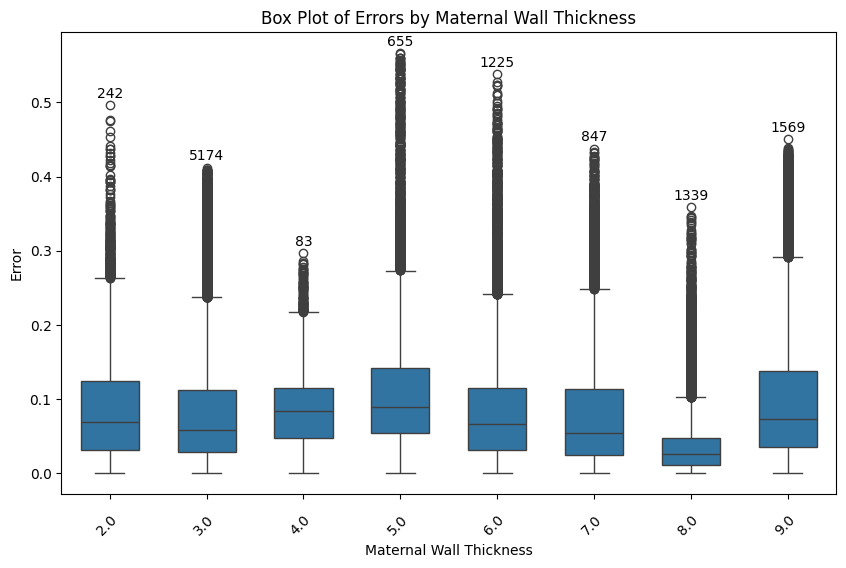

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the box plot
plt.figure(figsize=(10, 6))
box_plot = sns.boxplot(x='Maternal Wall Thickness', y='Error', data=results_df, width=0.6)

# Set plot title and labels
plt.title('Box Plot of Errors by Maternal Wall Thickness')
plt.xlabel('Maternal Wall Thickness')
plt.ylabel('Error')

# Adjust the padding between x-axis labels and the x-axis
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')  # Rotate labels for better readability
plt.gca().tick_params(axis='x', pad=10)

# Extract whisker information and add text above each box
ax = plt.gca()
whiskers = []
for i, line in enumerate(ax.get_lines()):
    if i % 6 == 5:  # Whiskers are the 5th and 6th lines for each box
        whisker_positions = line.get_ydata()
        whiskers.append(whisker_positions)
        if len(whisker_positions) == 0:
            continue
        box_center = line.get_xdata().mean()
        whisker_max = whisker_positions.max()
        ax.text(box_center, whisker_max + 0.01, f'{len(whisker_positions)}', 
                horizontalalignment='center', fontsize=10, color='black')
        # ax.text(box_center, whisker_max + 0.05, f'{mean_per_thickness[i//6]:.2f}',
        #         horizontalalignment='center', fontsize=10, color='black')
        # ax.text(box_center, whisker_max + 0.03, f'± {std_per_thickness[i//6]:.2f}',
        #         horizontalalignment='center', fontsize=10, color='black')

# Show the plot
plt.show()

About 3 or 4 times larger

In [65]:
len(results_df[results_df['Maternal Wall Thickness'] == 4])

14641

In [66]:
# Extract whisker information
for i, line in enumerate(box_plot.get_lines()):
    if i % 6 == 5:  # Whiskers are the 5th and 6th lines for each box
        print(f"Whisker {i // 6 + 1} positions: {line.get_ydata()}")

Whisker 1 positions: [0.2691375  0.26410425 0.28918725 0.30522552 0.26832277 0.28718054
 0.27403262 0.27780306 0.33095947 0.28864959 0.27604553 0.26732436
 0.2851015  0.26523012 0.26394853 0.27663347 0.27021125 0.28833392
 0.26904589 0.28305888 0.30573082 0.27248845 0.28105551 0.2822507
 0.27585173 0.28415543 0.26464337 0.27800107 0.26976645 0.29025641
 0.28040379 0.26524365 0.32112768 0.26756766 0.26950392 0.26356429
 0.2866956  0.26364911 0.2658093  0.26890671 0.29037338 0.26640004
 0.30754977 0.27964565 0.30494326 0.27764985 0.29476711 0.31333634
 0.26785862 0.28124917 0.26544076 0.28433082 0.28625008 0.27114382
 0.29888716 0.30462736 0.31655276 0.27143779 0.28327039 0.36044329
 0.28210613 0.2881602  0.30553052 0.3061533  0.33618078 0.28491172
 0.2967428  0.30042595 0.28508613 0.27045146 0.2750189  0.29382816
 0.31931132 0.27500382 0.31379515 0.28107005 0.31359413 0.29565138
 0.30836323 0.30372179 0.32496226 0.2876457  0.33710897 0.39591289
 0.3123666  0.35377613 0.41435871 0.320405

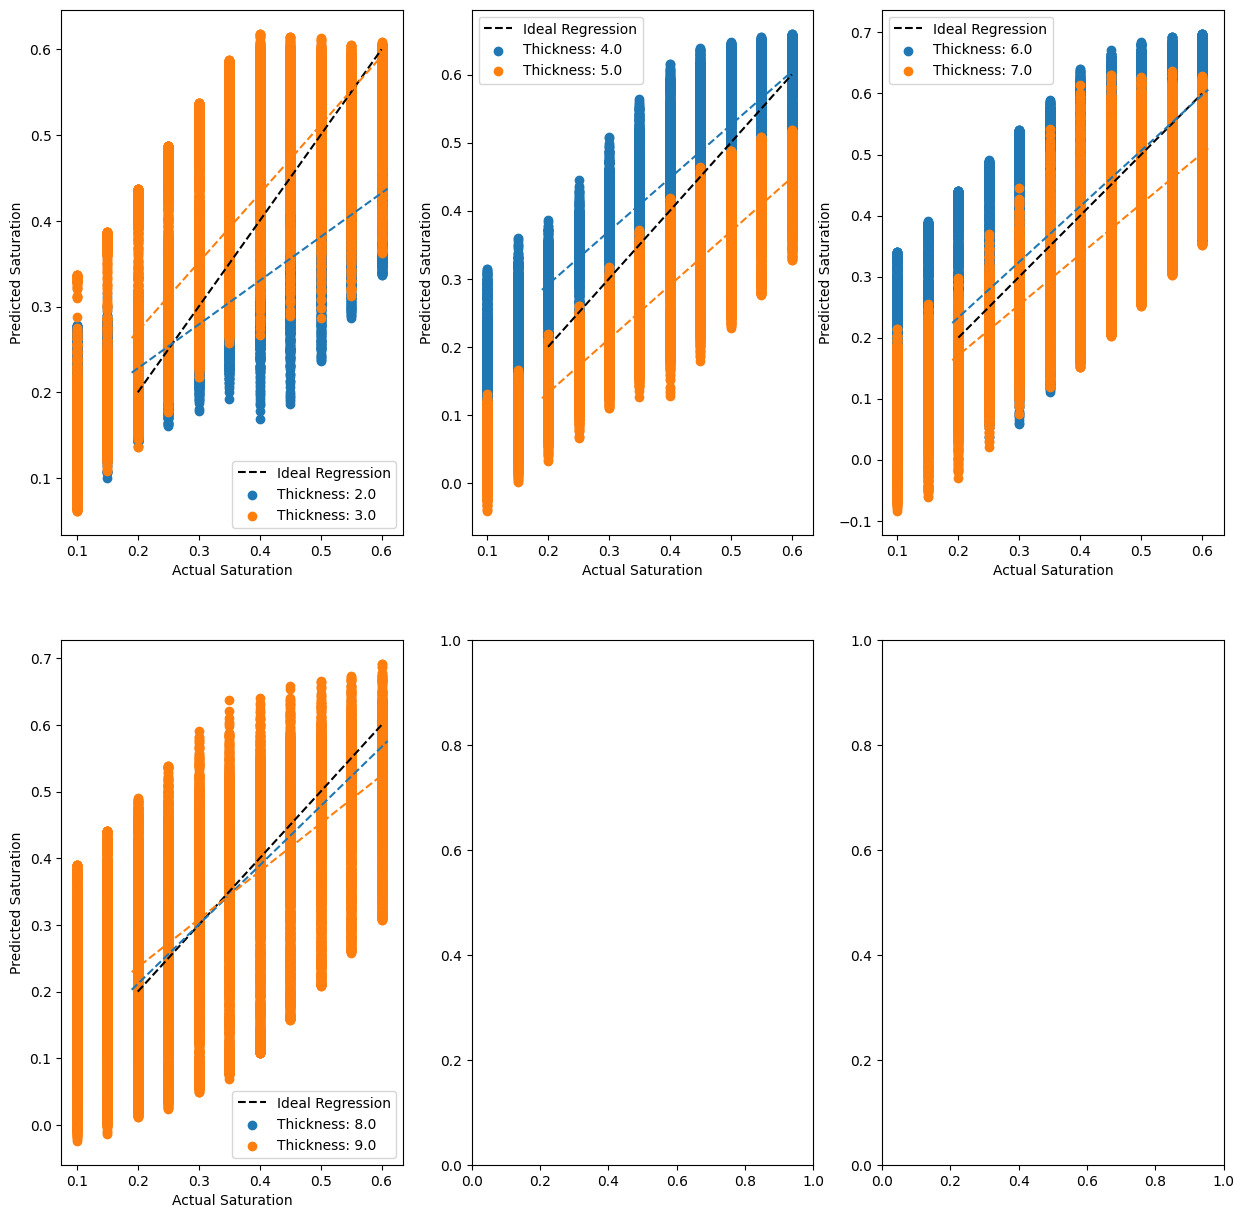

In [68]:
from scipy import stats

thickness_uniq = np.unique(results_df['Maternal Wall Thickness'])
# groups = [thickness_uniq[:5], thickness_uniq[5:10], thickness_uniq[10:15], thickness_uniq[15:]]
# groups = [[thickness] for thickness in thickness_uniq]
groups = [thickness_uniq[i:i+2] for i in range(0, len(thickness_uniq), 2)]

r_values = np.zeros((len(thickness_uniq),))
p_values = np.zeros((len(thickness_uniq),))

fig, axs = plt.subplots(2, 3, figsize=(15, 15))
axs = axs.flatten()
x_axis = np.linspace(0.19, 0.61, 140)

j = 0
for i, group in enumerate(groups):
    ax = axs[i]
    ax.plot([0.2, 0.6], [0.2, 0.6], color='black', linestyle='--', label='Ideal Regression')
    for thickness in group:
        data = results_df[results_df['Maternal Wall Thickness'] == thickness]
        data = data[~data['Error'].isin(whiskers[j])]
        ax.scatter(data['Actual Saturation'], data['Predicted Saturation'], label=f'Thickness: {thickness}')
        m, b = np.polyfit(data['Actual Saturation'], data['Predicted Saturation'], 1)
        ax.plot(x_axis, m*x_axis + b, linestyle='--') #, label=f'Fit: {thickness}'
        r_values[j], p_values[j] = stats.pearsonr(data['Actual Saturation'], data['Predicted Saturation'])
        j += 1
    ax.set_xlabel('Actual Saturation')
    ax.set_ylabel('Predicted Saturation')
    ax.legend()

In [69]:
stats_df = pd.DataFrame({'Thickness': thickness_uniq, 'R Value': r_values, 'P Value': p_values, 'MAE': mean_per_thickness, 'Std Dev': std_per_thickness})
stats_df.head(31)

,Thickness,R Value,P Value,MAE,Std Dev
0,2.0,0.854773,0.0,0.084661,0.066808
1,3.0,0.873310,0.0,0.091982,0.093048
2,4.0,0.883985,0.0,0.083763,0.046684
3,5.0,0.922646,0.0,0.109627,0.083563
4,6.0,0.840136,0.0,0.085279,0.073536
5,7.0,0.883100,0.0,0.077403,0.070524
6,8.0,0.971278,0.0,0.035678,0.036175
7,9.0,0.735421,0.0,0.100981,0.089278


Text(0.5, 1.0, 'MAE and Regression per Wall Thickness')

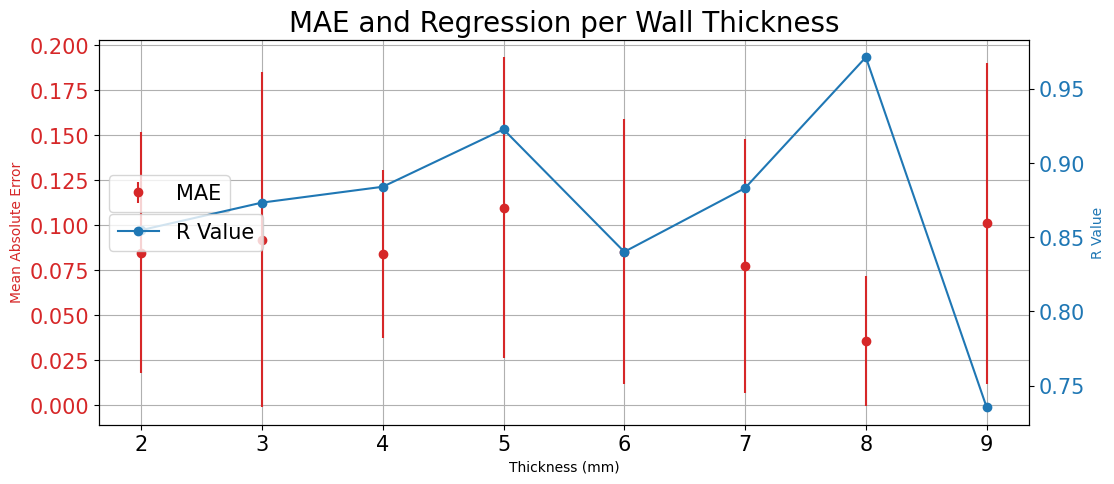

In [70]:
# ax = stats_df.plot(x='Thickness', y='R Value', kind='line', marker='o', figsize=(10, 6), title='R Value by Maternal Wall Thickness')
# ax.set_ylabel('R Value')

fig, ax = plt.subplots(figsize=(12, 5))
color = 'tab:red'

ax.errorbar(stats_df['Thickness'], stats_df['MAE'], yerr=stats_df['Std Dev'], fmt='o', color=color, label='MAE')
ax.set_ylabel('Mean Absolute Error', color=color)
ax.set_xlabel('Thickness (mm)')
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelcolor=color, labelsize=15)
ax.legend(loc='center left', bbox_to_anchor=(0, 0.6), fontsize=15)

ax.grid(True, which='both', axis='both')
ax.set_xticks(range(int(np.floor(stats_df['Thickness'].min())), int(np.floor(stats_df['Thickness'].max()))+1, 1))

ax2 = ax.twinx()
color = 'tab:blue'
ax2.set_ylabel('R Value', color=color)
ax2.plot(stats_df['Thickness'], stats_df['R Value'], 'o-', color=color, label='R Value')

ax2.tick_params(axis='y', labelcolor=color, labelsize=15)
ax2.legend(loc='center left', bbox_to_anchor=(0, 0.5), fontsize=15)
plt.title("MAE and Regression per Wall Thickness", fontsize=20)